# Feature engineering ciblé — `/predict`

**Objectif :** tester quelques interactions métier, identifier les variables réellement utiles, puis figer les variables de /predict.

Même protocole que les notebooks précédents : validation croisée à 5 folds sur le train, jeu de test réservé.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline

from agritech.config import SEED
from agritech.evaluation import regression_metrics
from agritech.modeling import FeatureEngineering, RunInfo, experiment_pipeline, run_experiment
from agritech.notification import notify
from agritech.predict_config import (
    PREDICT_CATEGORICAL,
    PREDICT_CV_FOLDS,
    PREDICT_CV_SHUFFLE,
    PREDICT_DATASET,
    PREDICT_FEATURES,
    PREDICT_FEATURES_DROP,
    PREDICT_NUMERIC,
    PREDICT_ROWS,
    PREDICT_SELECTED_FEATURES,
    PREDICT_TARGET,
    PREDICT_TEST_SIZE,
)
from agritech.preprocessing import build_pipeline
from agritech.tracking import run_tags, setup_mlflow
from agritech.training_data import feature_types, kfold_cv, load_dataset, protocol_params, split

# Données et protocole

Même protocole que le notebook 07. Le test reste réservé à l'évaluation finale.

In [2]:
df = load_dataset(PREDICT_DATASET, PREDICT_ROWS, PREDICT_FEATURES + [PREDICT_TARGET], non_negative=[PREDICT_TARGET])
X_train, X_test, y_train, y_test = split(df, PREDICT_FEATURES, PREDICT_TARGET, PREDICT_TEST_SIZE, SEED)
cv = kfold_cv(PREDICT_CV_FOLDS, PREDICT_CV_SHUFFLE, SEED)
CULTURES = sorted(df["Crop"].unique())

print("cultures :", CULTURES)

fichier            : data/processed/predict_training_dataset.csv
lignes x colonnes  : (999769, 10)
valeurs manquantes : 0
valeurs < 0        : 0 (Yield_tons_per_hectare)
total   : 999769 lignes
X_train : (799815, 9)
X_test  : (199954, 9), réservé à l'évaluation finale
y_train : (799815,)
y_test  : (199954,)
validation croisée : KFold(n_splits=5, random_state=42, shuffle=True)
cultures : ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']


In [3]:
# mêmes tags et mêmes paramètres de protocole pour tous les runs de ce notebook
experience = setup_mlflow("predict")
TAGS = run_tags(service="predict", stage="feature_engineering", notebook="08_predict_feature_engineering.ipynb")
PARAMS_PROTOCOLE = protocol_params(PREDICT_DATASET, X_train, X_test, PREDICT_TEST_SIZE, SEED, PREDICT_CV_FOLDS, PREDICT_CV_SHUFFLE)

expérience MLflow : oc_p12_agritech_predict


# Référence linéaire

Régression linéaire sur toutes les variables, recalculée pour avoir les scores par fold, sans nouveau run MLflow.

In [4]:
categorielles_toutes, numeriques_toutes = feature_types(PREDICT_FEATURES, PREDICT_CATEGORICAL, PREDICT_NUMERIC)
reference = build_pipeline(LinearRegression(), categorielles_toutes, numeriques_toutes)

folds_reference, metriques_reference = run_experiment(LinearRegression(), X_train, y_train, cv, categorielles_toutes, numeriques_toutes)

RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.4 s | CV complète : 2 s


# Interactions pluie, fertilisation et irrigation

Trois colonnes : fertilisation × irrigation, pluie × irrigation, pluie × fertilisation. Elles sont ajoutées dans le
pipeline, avant l'encodage : en validation croisée, elles sont calculées séparément dans chaque fold.

In [5]:
def ajouter_interactions_eau(X):
    """Ajoute les trois interactions entre pluie, fertilisation et irrigation."""
    X = X.copy()
    fertilisation = X["Fertilizer_Used"].astype(int)
    irrigation = X["Irrigation_Used"].astype(int)
    X["Fertilizer_x_Irrigation"] = fertilisation * irrigation
    X["Rainfall_x_Irrigation"] = X["Rainfall_mm"] * irrigation
    X["Rainfall_x_Fertilizer"] = X["Rainfall_mm"] * fertilisation
    return X

COLONNES_EAU = ["Fertilizer_x_Irrigation", "Rainfall_x_Irrigation", "Rainfall_x_Fertilizer"]
INTERACTIONS_EAU = FeatureEngineering(ajouter_interactions_eau, COLONNES_EAU)

folds_eau, metriques_eau = run_experiment(
    LinearRegression(), X_train, y_train, cv, categorielles_toutes, numeriques_toutes, engineering=INTERACTIONS_EAU,
    run=RunInfo("linear_regression_water_inputs_interactions_cv", "all_features", TAGS, PARAMS_PROTOCOLE),
)

linear_regression_water_inputs_interactions_cv
RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.5 s | CV complète : 3 s


**Observations :**

- Scores identiques à la référence à quatre décimales : les trois interactions n'apportent rien.

# Effets selon la culture

Pluie et température multipliées par l'indicatrice de chaque culture : une pente par culture, douze colonnes.

In [6]:
def ajouter_interactions_culture(X):
    """Ajoute, pour chaque culture, la pluie et la température limitées aux lignes de cette culture."""
    X = X.copy()
    for culture in CULTURES:
        est_cette_culture = (X["Crop"] == culture).astype(int)
        X[f"Rainfall_x_{culture}"] = X["Rainfall_mm"] * est_cette_culture
        X[f"Temperature_x_{culture}"] = X["Temperature_Celsius"] * est_cette_culture
    return X


COLONNES_CULTURE = [f"{variable}_x_{culture}" for variable in ["Rainfall", "Temperature"] for culture in CULTURES]
INTERACTIONS_CULTURE = FeatureEngineering(ajouter_interactions_culture, COLONNES_CULTURE)

folds_culture, metriques_culture = run_experiment(
    LinearRegression(), X_train, y_train, cv, categorielles_toutes, numeriques_toutes, engineering=INTERACTIONS_CULTURE,
    run=RunInfo("linear_regression_crop_interactions_cv", "all_features", TAGS, PARAMS_PROTOCOLE),
)

linear_regression_crop_interactions_cv
RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.6 s | CV complète : 4 s


**Observations :**

- Scores identiques à la référence : laisser varier la pente de la pluie et de la température selon la culture ne change
  rien.

# Forme de l'effet de la température

On regroupe les températures en 10 tranches et on regarde si le modèle se trompe davantage pour certaines températures.

In [7]:
predictions_hors_fold = cross_val_predict(reference, X_train, y_train, cv=cv)
residus = y_train - predictions_hors_fold

tranches = pd.qcut(X_train["Temperature_Celsius"], q=10)
residus_par_tranche = residus.groupby(tranches, observed=True).agg(["mean", "std", "count"])
residus_par_tranche.rename(columns={"mean": "erreur moyenne", "std": "dispersion", "count": "lignes"}).round(4)

,erreur moyenne,dispersion,lignes
Temperature_Celsius,,,
"(14.999, 17.495]",-0.0010,0.4992,79982
"(17.495, 20.002]",-0.0026,0.4998,79981
"(20.002, 22.509]",0.0029,0.5015,79982
"(22.509, 25.001]",0.0030,0.4999,79981
"(25.001, 27.51]",0.0006,0.4988,79982
"(27.51, 30.012]",0.0002,0.5013,79981
"(30.012, 32.511]",-0.0026,0.5015,79981
"(32.511, 35.009]",-0.0023,0.5011,79982
"(35.009, 37.512]",0.0027,0.5003,79981


**Observations :**

- L'erreur moyenne reste entre −0,003 et +0,003 t/ha dans toutes les tranches, sans tendance : l'effet de la température est
  linéaire, aucune colonne quadratique n'est testée.

# Importance des colonnes ajoutées

Pour comprendre le rôle des nouvelles colonnes, on analyse un seul fold représentatif de la validation croisée. On vérifie leur importance avec deux méthodes : permutation et SHAP. Les performances, elles, sont toujours comparées sur les 5 folds.

In [8]:
indices_apprentissage, indices_validation = next(cv.split(X_train))  # fold 1 de la validation croisée
X_apprentissage, y_apprentissage = X_train.iloc[indices_apprentissage], y_train.iloc[indices_apprentissage]
X_validation, y_validation = X_train.iloc[indices_validation], y_train.iloc[indices_validation]


def importance_des_colonnes(pipeline, nouvelles_colonnes):
    """Permutation et SHAP par colonne, sur le fold 1 : modèle ajusté sans les lignes de validation."""
    pipeline = clone(pipeline).fit(X_apprentissage, y_apprentissage)
    X_etendu = pipeline["features"].transform(X_validation)  # variables d'origine et colonnes ajoutées

    # scikit-learn utilise la RMSE négative car ses scores suivent la règle « plus grand = meilleur »
    permutation = permutation_importance(
        Pipeline(pipeline.steps[1:]), X_etendu, y_validation,
        scoring="neg_root_mean_squared_error", n_repeats=5, random_state=SEED,
    )
    hausse_rmse = pd.Series(permutation.importances_mean, index=X_etendu.columns)

    # SHAP
    echantillon = pipeline["preprocessing"].transform(X_etendu.sample(5000, random_state=SEED))
    explicateur = shap.LinearExplainer(pipeline["model"], shap.maskers.Independent(echantillon, max_samples=len(echantillon)))
    valeurs = explicateur.shap_values(echantillon)

    # colonnes one-hot d'une même variable regroupées ; colonnes ajoutées gardées séparées
    colonnes_encodees = pipeline["preprocessing"].get_feature_names_out()
    shap_moyen = {}
    for variable in list(X_etendu.columns):
        appartient = [c == f"numeric__{variable}" or c.startswith(f"categorical__{variable}_") for c in colonnes_encodees]
        shap_moyen[variable] = np.abs(valeurs[:, appartient].sum(axis=1)).mean()

    resultat = pd.DataFrame({"hausse_rmse": hausse_rmse, "shap_moyen": pd.Series(shap_moyen)})
    resultat["ajoutée"] = resultat.index.isin(nouvelles_colonnes)
    return resultat.sort_values("shap_moyen", ascending=False)

In [9]:
importance_eau = importance_des_colonnes(
    experiment_pipeline(LinearRegression(), categorielles_toutes, numeriques_toutes, INTERACTIONS_EAU), COLONNES_EAU
)
importance_eau.round(4)

,hausse_rmse,shap_moyen,ajoutée
Rainfall_mm,1.4006,1.1350,False
Fertilizer_Used,0.6739,0.7492,False
Irrigation_Used,0.4821,0.5978,False
Temperature_Celsius,0.0396,0.1242,False
Soil_Type,0.0000,0.0018,False
Fertilizer_x_Irrigation,0.0000,0.0016,True
Crop,-0.0000,0.0013,False
Days_to_Harvest,0.0000,0.0011,False
Region,0.0000,0.0007,False
Rainfall_x_Irrigation,0.0000,0.0005,True


In [10]:
importance_culture = importance_des_colonnes(
    experiment_pipeline(LinearRegression(), categorielles_toutes, numeriques_toutes, INTERACTIONS_CULTURE), COLONNES_CULTURE
)
importance_culture.round(4)

,hausse_rmse,shap_moyen,ajoutée
Rainfall_mm,1.1498,0.9731,False
Fertilizer_Used,0.6753,0.7503,False
Irrigation_Used,0.4839,0.5992,False
Rainfall_x_Wheat,0.0534,0.1102,True
Rainfall_x_Soybean,0.0528,0.1093,True
Rainfall_x_Rice,0.0518,0.1080,True
Rainfall_x_Barley,0.0514,0.1072,True
Rainfall_x_Maize,0.0509,0.1070,True
Temperature_Celsius,0.0294,0.1065,False
Rainfall_x_Cotton,0.0496,0.1058,True


Mêmes valeurs en figure, triées : vert pour les variables d'origine, ocre pour les colonnes ajoutées.

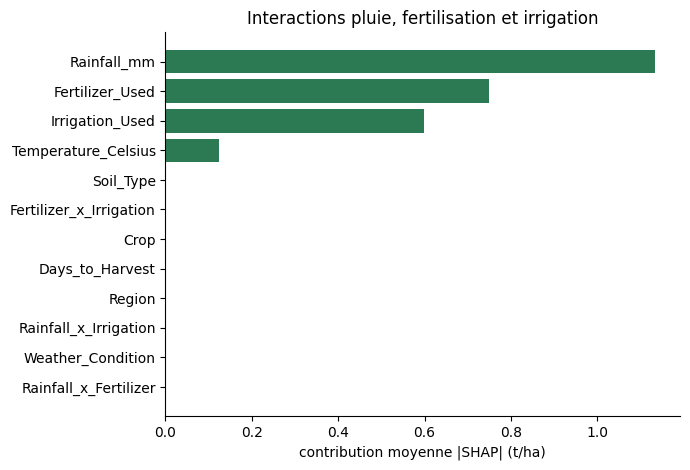

In [11]:
def figure_importance(importances, titre):
    """Barres horizontales de la contribution SHAP moyenne, colonnes ajoutées mises en évidence."""
    donnees = importances.sort_values("shap_moyen")
    couleurs = ["#b35c00" if ajoutee else "#2c7a53" for ajoutee in donnees["ajoutée"]]

    figure, axes = plt.subplots(figsize=(7, 0.3 * len(donnees) + 1.2))
    axes.barh(donnees.index, donnees["shap_moyen"], color=couleurs)
    axes.set_xlabel("contribution moyenne |SHAP| (t/ha)")
    axes.set_title(titre)
    axes.spines[["top", "right"]].set_visible(False)
    figure.tight_layout()
    plt.show()


figure_importance(importance_eau, "Interactions pluie, fertilisation et irrigation")

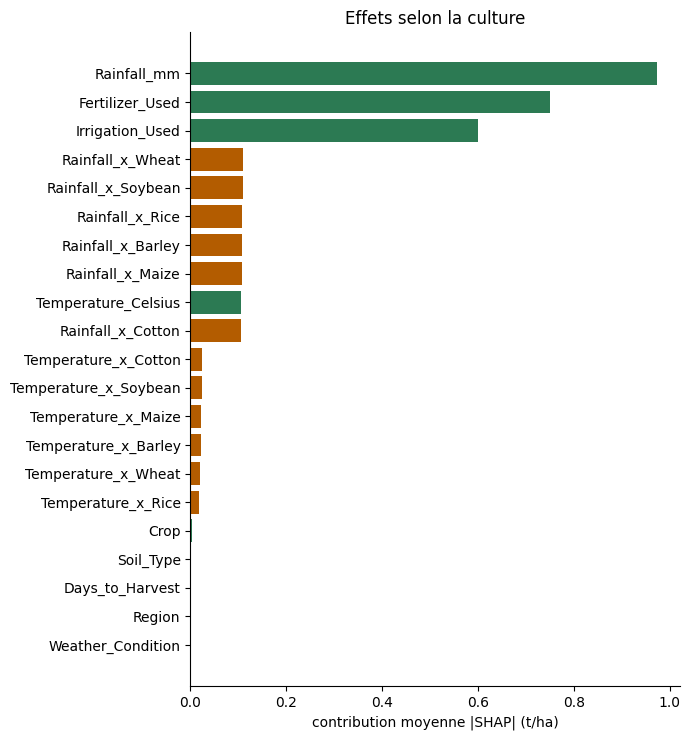

In [12]:
figure_importance(importance_culture, "Effets selon la culture")

**Observations :**

- Les trois interactions pluie, fertilisation et irrigation reçoivent une contribution quasi nulle, au niveau des variables sans effet :
  aucun signal.
- Les colonnes pluie × culture, elles, reçoivent une contribution visible, mais la pluie seule en perd d'autant : les six
  colonnes s'additionnent exactement en `Rainfall_mm`, l'information est redistribuée entre colonnes liées plutôt
  qu'ajoutée, et la RMSE ne bouge pas. Même lecture, en plus petit, pour température × culture.

# Variables sélectionnées

Régression linéaire sur toutes les variables, sur les variables réduites, sur les 4 variables sélectionnées
(`PREDICT_SELECTED_FEATURES`) : pluie, température, fertilisation et irrigation, et sur ces 4 variables plus `Crop`.

Chaque entraînement utilise la même régression linéaire, le même preprocessing et les mêmes 5 folds ; seules les variables d'entrée changent.

| Entraînement | Variables d'entrée | Nombre |
|---|---|---:|
| toutes les variables (référence) | `Crop`, `Soil_Type`, `Fertilizer_Used`, `Irrigation_Used`, `Region`, `Weather_Condition`, `Rainfall_mm`, `Temperature_Celsius`, `Days_to_Harvest` | 9 |
| variables réduites | toutes sauf `Region`, `Weather_Condition` et `Days_to_Harvest`, soit `Crop`, `Soil_Type`, `Fertilizer_Used`, `Irrigation_Used`, `Rainfall_mm`, `Temperature_Celsius` | 6 |
| variables sélectionnées + `Crop` | `Crop`, `Rainfall_mm`, `Temperature_Celsius`, `Fertilizer_Used`, `Irrigation_Used` | 5 |
| variables sélectionnées | `Rainfall_mm`, `Temperature_Celsius`, `Fertilizer_Used`, `Irrigation_Used` | 4 |

La référence est celle calculée plus haut ; les trois autres jeux sont entraînés ci-dessous.

In [13]:
VARIABLES_REDUITES = [variable for variable in PREDICT_FEATURES if variable not in PREDICT_FEATURES_DROP]
VARIABLES_SELECTIONNEES_ET_CROP = ["Crop"] + PREDICT_SELECTED_FEATURES

categorielles_reduites, numeriques_reduites = feature_types(VARIABLES_REDUITES, PREDICT_CATEGORICAL, PREDICT_NUMERIC)
folds_reduites, metriques_reduites = run_experiment(LinearRegression(), X_train, y_train, cv, categorielles_reduites, numeriques_reduites)

RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.3 s | CV complète : 2 s


In [14]:
categorielles_crop, numeriques_crop = feature_types(VARIABLES_SELECTIONNEES_ET_CROP, PREDICT_CATEGORICAL, PREDICT_NUMERIC)
lineaire_crop = build_pipeline(LinearRegression(), categorielles_crop, numeriques_crop)

folds_crop, metriques_crop = run_experiment(
    LinearRegression(), X_train, y_train, cv, categorielles_crop, numeriques_crop,
    run=RunInfo("linear_regression_selected_features_plus_crop_cv", "selected_features_plus_crop", TAGS, PARAMS_PROTOCOLE),
)

linear_regression_selected_features_plus_crop_cv
RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.2 s | CV complète : 1 s


In [15]:
categorielles_selection, numeriques_selection = feature_types(PREDICT_SELECTED_FEATURES, PREDICT_CATEGORICAL, PREDICT_NUMERIC)
lineaire_selection = build_pipeline(LinearRegression(), categorielles_selection, numeriques_selection)

folds_selection, metriques_selection = run_experiment(
    LinearRegression(), X_train, y_train, cv, categorielles_selection, numeriques_selection,
    run=RunInfo("linear_regression_selected_features_cv", "selected_features", TAGS, PARAMS_PROTOCOLE),
)

linear_regression_selected_features_cv
RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.1 s | CV complète : 1 s


In [16]:
resumes = {
    "toutes les variables (9), référence": metriques_reference,
    "variables réduites (6)": metriques_reduites,
    "variables sélectionnées + Crop (5)": metriques_crop,
    "variables sélectionnées (4)": metriques_selection,
    "toutes les variables + interactions pluie, fertilisation et irrigation": metriques_eau,
    "toutes les variables + effets selon la culture": metriques_culture,
}
COLONNES = ["cv_rmse_mean", "cv_rmse_std", "cv_mae_mean", "cv_r2_mean", "cv_fit_time_mean"]

comparaison = pd.DataFrame(resumes).T[COLONNES].sort_values("cv_rmse_mean")
comparaison.round({"cv_rmse_mean": 6, "cv_rmse_std": 6, "cv_mae_mean": 4, "cv_r2_mean": 4, "cv_fit_time_mean": 1})

,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,cv_fit_time_mean
variables sélectionnées (4),0.500332,0.000896,0.3993,0.9129,0.1
variables sélectionnées + Crop (5),0.500333,0.000896,0.3993,0.9129,0.2
variables réduites (6),0.500334,0.000894,0.3993,0.9129,0.3
"toutes les variables (9), référence",0.500337,0.000893,0.3993,0.9129,0.4
"toutes les variables + interactions pluie, fertilisation et irrigation",0.500338,0.000898,0.3993,0.9129,0.5
toutes les variables + effets selon la culture,0.500341,0.000892,0.3993,0.9129,0.6


Les performances sont pratiquement identiques quelle que soit la configuration : les interactions et les variables supplémentaires n’apportent pas d’amélioration mesurable.

In [17]:
ecart_avec_crop = folds_crop["rmse"] - folds_selection["rmse"]

print(f"écart de RMSE moyenne, avec − sans Crop : {ecart_avec_crop.mean():+.6f} t/ha")
print(f"écart min et max entre folds            : {ecart_avec_crop.min():+.6f} / {ecart_avec_crop.max():+.6f} t/ha")
print(f"colonnes après encodage                 : {len(categorielles_selection) + len(numeriques_selection)} variables → "
      f"{lineaire_selection[:-1].fit_transform(X_train[PREDICT_SELECTED_FEATURES]).shape[1]} colonnes | "
      f"{len(VARIABLES_SELECTIONNEES_ET_CROP)} variables → {lineaire_crop[:-1].fit_transform(X_train[VARIABLES_SELECTIONNEES_ET_CROP]).shape[1]} colonnes")

écart de RMSE moyenne, avec − sans Crop : +0.000002 t/ha
écart min et max entre folds            : -0.000001 / +0.000004 t/ha
colonnes après encodage                 : 4 variables → 6 colonnes | 5 variables → 12 colonnes


**Observations :**

- Les six configurations ont des performances pratiquement identiques : aucune variable ou interaction ajoutée n’apporte d’amélioration mesurable.
- Ajouter Crop aux 4 variables sélectionnées ne change pratiquement pas la RMSE et fait passer le modèle de 6 à 12 colonnes après encodage.

# Coefficients de la régression linéaire

Régression linéaire sur les 4 variables sélectionnées, ajustée sur la partie apprentissage du fold 1, avec les deux variables
oui/non codées 0 et 1 : les coefficients sont alors directement lisibles.

In [18]:
def en_nombres(X):
    """Les 4 variables sélectionnées sous forme numérique : les deux variables oui/non deviennent 0 et 1."""
    return X[PREDICT_SELECTED_FEATURES].astype(float)


regression_selection = LinearRegression().fit(en_nombres(X_apprentissage), y_apprentissage)
coefficients = pd.Series(regression_selection.coef_, index=PREDICT_SELECTED_FEATURES)

print(f"Point de départ de la prédiction : {regression_selection.intercept_:.6f}")
print(coefficients.round(6).to_string())
print("\nYield ≈ " + f"{regression_selection.intercept_:.4f} + " + " + ".join(f"{valeur:.4f} × {nom}" for nom, valeur in coefficients.items()))

Point de départ de la prédiction : 0.007316
Rainfall_mm            0.004993
Temperature_Celsius    0.019895
Fertilizer_Used        1.500744
Irrigation_Used        1.199624

Yield ≈ 0.0073 + 0.0050 × Rainfall_mm + 0.0199 × Temperature_Celsius + 1.5007 × Fertilizer_Used + 1.1996 × Irrigation_Used


In [19]:
# la formule reconstruite à la main doit redonner exactement les prédictions du modèle
prediction_manuelle = regression_selection.intercept_ + en_nombres(X_validation) @ coefficients
ecart_formule = np.abs(prediction_manuelle - regression_selection.predict(en_nombres(X_validation))).max()

rmse_variables_01 = regression_metrics(y_validation, regression_selection.predict(en_nombres(X_validation)), prefix="validation")["validation_rmse"]
rmse_encodage_onehot = regression_metrics(
    y_validation,
    clone(lineaire_selection).fit(X_apprentissage[PREDICT_SELECTED_FEATURES], y_apprentissage).predict(X_validation[PREDICT_SELECTED_FEATURES]),
    prefix="validation",
)["validation_rmse"]

print(f"écart maximal entre la formule et le modèle : {ecart_formule:.2e} t/ha")
print(f"RMSE sur ce fold : {rmse_variables_01:.6f} (variables en 0/1) contre {rmse_encodage_onehot:.6f} (encodage one-hot)")

écart maximal entre la formule et le modèle : 0.00e+00 t/ha
RMSE sur ce fold : 0.499270 (variables en 0/1) contre 0.499270 (encodage one-hot)


Formule reconstruite avec les coefficients appris :

`Yield ≈ 0,0073 + 0,0050 × Rainfall_mm + 0,0199 × Temperature_Celsius + 1,5007 × Fertilizer_Used + 1,1996 × Irrigation_Used`

**Observations :**

- Les coefficients appris sont très proches de valeurs rondes. La régression linéaire retrouve donc une relation
  particulièrement simple entre ces quatre variables et le rendement.
- La formule recalculée à la main redonne exactement les prédictions du modèle.
- Les variables en 0/1 et l'encodage one-hot donnent la même RMSE.

# Effet de `Crop` à conditions identiques

Sur un échantillon du fold de validation, les mêmes conditions sont rejouées avec les 6 cultures : on mesure l'écart entre
la plus forte et la plus faible prédiction du modèle aux variables sélectionnées plus `Crop`.

In [20]:
modele_crop_fold_1 = clone(lineaire_crop).fit(X_apprentissage[VARIABLES_SELECTIONNEES_ET_CROP], y_apprentissage)
echantillon_cultures = X_validation[VARIABLES_SELECTIONNEES_ET_CROP].sample(2000, random_state=SEED)

predictions_par_culture = {}
for culture in CULTURES:
    conditions = echantillon_cultures.copy()
    conditions["Crop"] = culture
    predictions_par_culture[culture] = modele_crop_fold_1.predict(conditions)

predictions_par_culture = pd.DataFrame(predictions_par_culture, index=echantillon_cultures.index)
amplitude = predictions_par_culture.max(axis=1) - predictions_par_culture.min(axis=1)

print(f"amplitude entre cultures, à conditions identiques : moyenne {amplitude.mean():.4f} | médiane {amplitude.median():.4f} | maximum {amplitude.max():.4f} t/ha")
print(f"à comparer à la RMSE de la régression linéaire : {metriques_selection['cv_rmse_mean']:.4f} t/ha")
print("\nrendement moyen prédit par culture :")
print(predictions_par_culture.mean().round(4).to_string())

amplitude entre cultures, à conditions identiques : moyenne 0.0033 | médiane 0.0033 | maximum 0.0033 t/ha
à comparer à la RMSE de la régression linéaire : 0.5003 t/ha

rendement moyen prédit par culture :
Barley     4.6512
Cotton     4.6506
Maize      4.6485
Rice       4.6506
Soybean    4.6481
Wheat      4.6480


**Observations :**

- À conditions identiques, changer uniquement la culture modifie la prédiction d'environ 0,003 t/ha. C'est négligeable
  par rapport à une RMSE d'environ 0,50 t/ha.
- L'amplitude est la même pour toutes les lignes : le modèle étant linéaire, l'effet de la culture ne dépend pas des
  conditions.

# Conclusion

**Observations :**

- quatre variables portent le signal principal : pluie, température, fertilisation et irrigation ; ce sont les
  variables sélectionnées pour la suite (`PREDICT_SELECTED_FEATURES`) ;
- les interactions testées n'améliorent pas la RMSE ;
- la régression linéaire retrouve une relation simple, avec des coefficients proches de valeurs rondes ;
- à conditions identiques, `Crop` ne modifie la prédiction que d’environ 0,003 t/ha et n’améliore pas les performances ; elle est donc écartée du modèle actuel ;
- `Crop` reste néanmoins une information métier de l’application et pourra être réintégrée si de futures données montrent un effet utile sur le rendement.

In [21]:
notify(
    "Agritech /predict",
    f"Feature engineering terminé — meilleure RMSE CV {comparaison['cv_rmse_mean'].iloc[0]:.6f} ({comparaison.index[0]})",
)